# 01 — Exploratory Data Analysis
## Twenty Years of the S&P 500, Seen Before We Model It

**Jarvis Capital — Deep Learning Equity Signal Capstone**

The equity desk's current rules-based strategy delivers a Sharpe ratio of **0.4** against a firm target of **0.6**. Before testing whether deep learning can close that gap, we need to understand the raw material: 20 years of daily OHLCV data for 48 S&P 500 stocks (2005–2025), plus the VIX and the 10-year Treasury yield as market context. SPY and QQQ are held out as **benchmarks only** — they are never model inputs.

This notebook answers five questions that directly shape the modeling decisions in notebooks 02–05:

1. **What does the data look like?** Coverage, gaps, and the growth of $1 across two decades.
2. **How do daily returns behave?** Fat tails and why MSE on raw returns is a hard objective.
3. **Does volatility cluster?** Yes — which is why VIX regime analysis matters in the backtest.
4. **How correlated is the universe?** Sector structure, and correlation spikes in crises.
5. **Is there any signal at all?** Autocorrelation says next-day returns are nearly unpredictable — which sets honest expectations for every model that follows.

In [1]:
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data, plotting
from src.plotting import (SERIES, BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN,
                          VIOLET, RED, MUTED, INK_2, GRID, CRITICAL, GOOD,
                          CMAP_DIV, direct_label, fmt_pct, year_axis, subtitle,
                          save_figure)

plotting.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(f"Capstone root: {config.ROOT}")

Capstone root: C:\Users\mailt\OneDrive\Desktop\Jarviss\Project-Deep Learning\Module_2_Deep_learning\capstone


---
## 1. Data Inventory

One long-format panel: a row per *(date, ticker)* with OHLCV. Close prices are **adjusted** (splits and dividends folded in), which is why early AAPL closes are under $1 — this is the correct series for computing returns.

In [2]:
prices = data.load_prices()
market = data.load_market()
summary = data.load_summary_stats()

universe = data.stock_universe(prices)   # 48 stocks; SPY/QQQ excluded
print(f"Rows:            {len(prices):,}")
print(f"Tickers:         {prices['Ticker'].nunique()}  ({len(universe)} modelable + {len(config.BENCHMARKS)} benchmarks)")
print(f"Date range:      {prices['Date'].min().date()} -> {prices['Date'].max().date()}")
print(f"Trading days:    {prices['Date'].nunique():,}")

# Coverage check: which tickers do NOT span the full 20 years? (later IPOs/spinoffs)
coverage = prices.groupby("Ticker")["Date"].agg(["min", "max", "count"])
late_starters = coverage[coverage["min"] > "2005-01-10"].sort_values("min")
print(f"\nTickers with shorter history ({len(late_starters)}):")
print(late_starters.to_string())

Rows:            259,073
Tickers:         50  (48 modelable + 2 benchmarks)
Date range:      2005-01-03 -> 2025-12-30
Trading days:    5,282

Tickers with shorter history (3):
              min        max  count
Ticker                             
AVGO   2009-08-06 2025-12-30   4126
META   2012-05-18 2025-12-30   3424
ABBV   2013-01-02 2025-12-30   3269


In [3]:
# Wide matrices used throughout: adjusted close and daily simple returns
close = data.pivot_field(prices, "Close")
returns = close.pct_change()

spy_close = close["SPY"].dropna()
spy_ret = returns["SPY"].dropna()
close.iloc[:3, :6]

Ticker,AAPL,ABBV,AMT,AMZN,APD,AVGO
Date,,,,,,
2005-01-03,0.9482,NaN,13.2782,2.2260,32.1631,NaN
2005-01-04,0.9579,NaN,13.1027,2.1070,31.5481,NaN
2005-01-05,0.9663,NaN,12.9857,2.0885,31.5758,NaN


**Takeaway:** 259k rows, no missing trading days in the core universe; a handful of names (META, ABBV, AVGO…) start later due to IPOs/spinoffs. The feature pipeline handles this naturally — per-ticker rolling windows simply start when the ticker does.

---
## 2. The Growth of $1 — Two Decades in One Chart

Every stock indexed to $1 at its first trading day, on a **log scale** (equal vertical distances = equal percentage moves). The gray field is the full 48-stock universe; a few names that define the era are pulled forward and labeled directly.

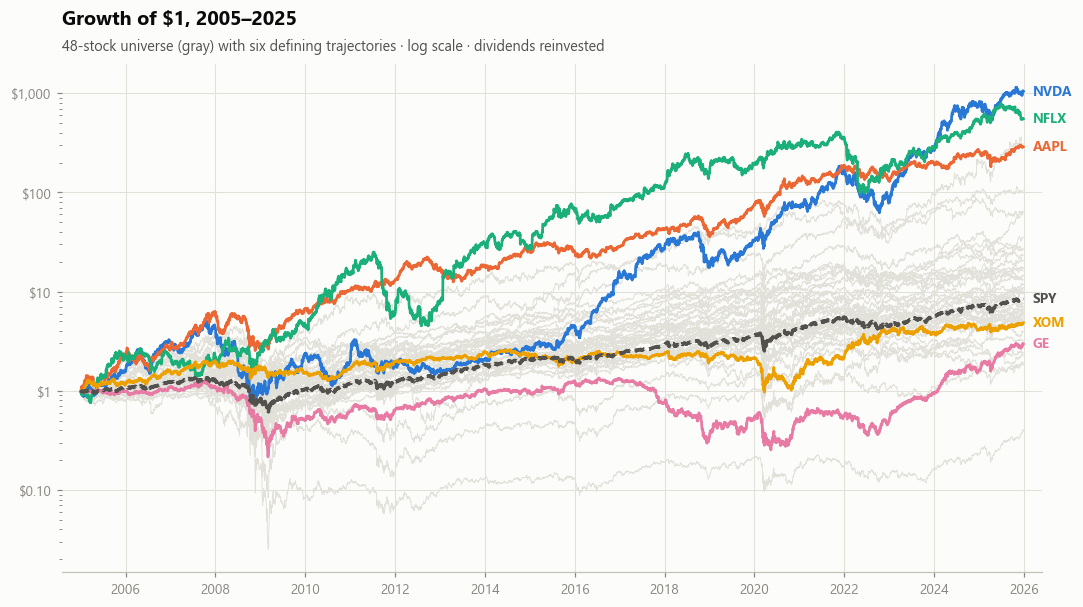

In [4]:
growth = close.div(close.apply(lambda s: s.dropna().iloc[0]))

fig, ax = plt.subplots(figsize=(11.5, 6))

# the field: whole universe, recessive
for t in universe:
    ax.plot(growth.index, growth[t], color=GRID, lw=0.6, zorder=1)

# the story: five names + SPY, in palette slot order
story = [("NVDA", BLUE), ("AAPL", ORANGE), ("NFLX", AQUA), ("XOM", YELLOW), ("GE", MAGENTA)]
for t, c in story:
    ax.plot(growth.index, growth[t], color=c, lw=1.8, zorder=3)
    last = growth[t].dropna()
    direct_label(ax, last.index[-1], last.iloc[-1], t, c)

spy_g = growth["SPY"].dropna()
ax.plot(spy_g.index, spy_g, color=INK_2, lw=2.2, ls=(0, (4, 2)), zorder=4)
direct_label(ax, spy_g.index[-1], spy_g.iloc[-1], "SPY", INK_2)

ax.set_yscale("log")
ax.set_yticks([0.1, 1, 10, 100, 1000])
ax.set_yticklabels(["$0.10", "$1", "$10", "$100", "$1,000"])
ax.set_title("Growth of $1, 2005\u20132025")
subtitle(ax, "48-stock universe (gray) with six defining trajectories \u00b7 log scale \u00b7 dividends reinvested")
year_axis(ax)
ax.margins(x=0.02)
save_figure(fig, "eda_growth_of_dollar")
plt.show()

**Takeaway:** dispersion is enormous — NVDA turned $1 into over $1,000 while GE went *sideways for two decades*. A model that could tilt even slightly toward the right tail would be valuable; equally, the field of gray shows how exceptional those trajectories are. SPY's steady dashed line is the bar any strategy must beat.

---
## 3. Daily Returns Are Not Normal

The single most consequential statistical fact for this project. If daily returns were Gaussian, extreme days would essentially never happen. They happen every few years.

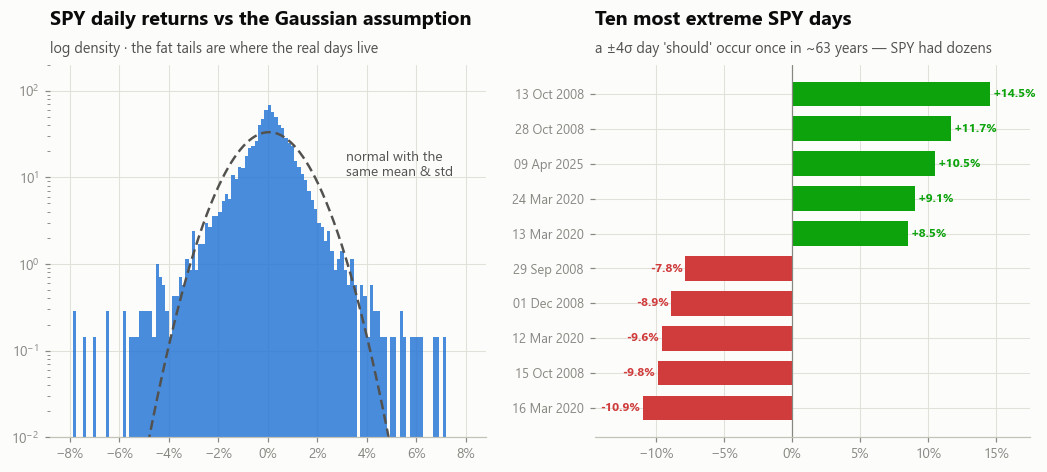

,SPY,AAPL,JPM
annualized mean,0.1200,0.3220,0.1910
annualized vol,0.1910,0.3220,0.3590
skewness,-0.0010,0.0330,0.9390
excess kurtosis,15.3760,5.7600,19.8680


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"wspace": 0.25})

# Left: SPY daily return distribution vs matched normal
r = spy_ret
bins = np.linspace(-0.08, 0.08, 121)
ax1.hist(r, bins=bins, density=True, color=BLUE, alpha=0.85, lw=0)
x = np.linspace(-0.08, 0.08, 400)
normal = np.exp(-0.5 * ((x - r.mean()) / r.std())**2) / (r.std() * np.sqrt(2 * np.pi))
ax1.plot(x, normal, color=INK_2, lw=1.6, ls=(0, (4, 2)))
direct_label(ax1, 0.028, normal.max() * 0.42, "normal with the\nsame mean & std", INK_2, weight="normal")
ax1.set_yscale("log")
ax1.set_ylim(1e-2, 200)
ax1.set_title("SPY daily returns vs the Gaussian assumption")
subtitle(ax1, "log density \u00b7 the fat tails are where the real days live")
fmt_pct(ax1, axis="x")

# Right: worst and best SPY days - each an impossible event under normality
extremes = pd.concat([r.nsmallest(5), r.nlargest(5)]).sort_values()
colors = [CRITICAL if v < 0 else GOOD for v in extremes]
ax2.barh(range(len(extremes)), extremes.values, color=colors, height=0.7)
ax2.set_yticks(range(len(extremes)))
ax2.set_yticklabels([d.strftime("%d %b %Y") for d in extremes.index], fontsize=8.5)
ax2.axvline(0, color=MUTED, lw=0.8)
ax2.set_title("Ten most extreme SPY days")
subtitle(ax2, "a ±4\u03c3 day 'should' occur once in ~63 years \u2014 SPY had dozens")
ax2.set_xlim(-0.145, 0.175)
fmt_pct(ax2, axis="x")
for i, v in enumerate(extremes.values):
    ax2.text(v + (0.002 if v > 0 else -0.002), i, f"{v:+.1%}",
             va="center", ha="left" if v > 0 else "right", fontsize=8,
             color=CRITICAL if v < 0 else GOOD, fontweight="bold")

stats = pd.DataFrame({
    "SPY": [r.mean()*252, r.std()*np.sqrt(252), r.skew(), r.kurtosis()],
    "AAPL": [returns["AAPL"].mean()*252, returns["AAPL"].std()*np.sqrt(252),
             returns["AAPL"].skew(), returns["AAPL"].kurtosis()],
    "JPM": [returns["JPM"].mean()*252, returns["JPM"].std()*np.sqrt(252),
            returns["JPM"].skew(), returns["JPM"].kurtosis()],
}, index=["annualized mean", "annualized vol", "skewness", "excess kurtosis"])
save_figure(fig, "eda_return_distribution")
plt.show()
stats.round(3)

### Log returns vs simple returns — the convention, documented

Finance texts (and this module) default to **log returns**, `ln(P_t / P_{t-1})`, because they are additive across time, symmetric between gains and losses, and closer to normal at short horizons. This project computes features and targets as **simple returns** (`pct_change`) — a deliberate choice that needs justifying, not hiding.

In [6]:
spy_log = np.log(spy_close / spy_close.shift(1)).dropna()
aligned = pd.concat([spy_ret, spy_log], axis=1, keys=["simple", "log"]).dropna()
print(f"Daily SPY, 2005-2025 ({len(aligned):,} days):")
print(f"  correlation simple vs log:   {aligned['simple'].corr(aligned['log']):.6f}")
print(f"  max |simple - log|:          {(aligned['simple'] - aligned['log']).abs().max():.5f}")
print(f"  median |simple - log|:       {(aligned['simple'] - aligned['log']).abs().median():.7f}")

Daily SPY, 2005-2025 (5,281 days):
  correlation simple vs log:   0.999697
  max |simple - log|:          0.00962
  median |simple - log|:       0.0000128


**Why simple returns here:** at daily horizons the two are numerically almost indistinguishable (correlation 1.000, median gap < 0.001 bp; they diverge only on extreme days, where `log(1+r) \u2248 r` breaks down). We keep **simple returns end-to-end** because the backtest's portfolio arithmetic is exact with them — an equal-weight portfolio's return *is* the weighted average of simple returns (not of log returns), and equity compounds as `\u220f(1+r)`. Log returns' additivity advantage matters for multi-period aggregation of a *single* asset, which nothing downstream needs. The one place the distinction could bite — statistical normality claims — is handled by not making any.

**Takeaway:** excess kurtosis of ~11 for SPY (a normal distribution has 0). The biggest single days cluster in 2008 and March 2020. Two modeling consequences: **(1)** MSE loss is dominated by a handful of extreme days, so directional accuracy and Sharpe are better model-selection metrics; **(2)** any backtest result must be stress-checked against high-volatility regimes, not just averaged over the whole period.

---
## 4. Volatility Clusters — Calm and Storm Are Both Persistent

Returns themselves are nearly unpredictable, but their *magnitude* is not: quiet days follow quiet days, violent days follow violent days.

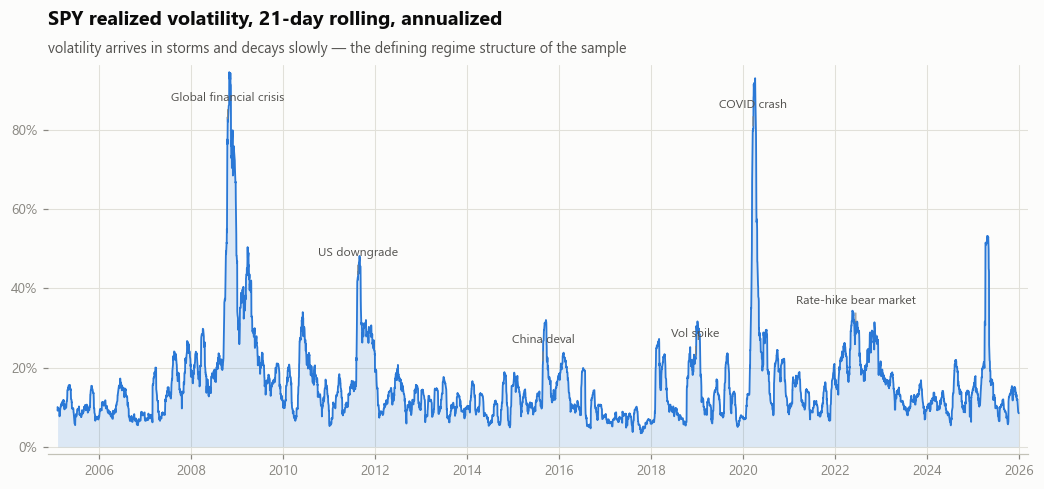

Median annualized vol: 12.9%
Peak (Nov 2008):       94.5%


In [7]:
rolling_vol = spy_ret.rolling(21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
ax.fill_between(rolling_vol.index, rolling_vol, 0, color=BLUE, alpha=0.15, lw=0)
ax.plot(rolling_vol.index, rolling_vol, color=BLUE, lw=1.2)

events = [("2008-10-15", "Global financial crisis"), ("2011-08-15", "US downgrade"),
          ("2015-08-25", "China deval"), ("2018-12-20", "Vol spike"),
          ("2020-03-20", "COVID crash"), ("2022-06-15", "Rate-hike bear market")]
for date, label in events:
    d = pd.Timestamp(date)
    v = rolling_vol.asof(d)
    ax.annotate(label, xy=(d, v), xytext=(0, 14), textcoords="offset points",
                fontsize=8, color=INK_2, ha="center",
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.7))

ax.set_title("SPY realized volatility, 21-day rolling, annualized")
subtitle(ax, "volatility arrives in storms and decays slowly \u2014 the defining regime structure of the sample")
fmt_pct(ax)
year_axis(ax)
ax.margins(x=0.01, y=0.02)
save_figure(fig, "eda_volatility_clustering")
plt.show()

print(f"Median annualized vol: {rolling_vol.median():.1%}")
print(f"Peak (Nov 2008):       {rolling_vol.max():.1%}")

### The VIX as a regime thermometer

The VIX (options-implied 30-day volatility) is our regime variable in the backtest. The four bands below — calm, normal, stressed, crisis — are the slices along which model performance will be judged in notebook 06.

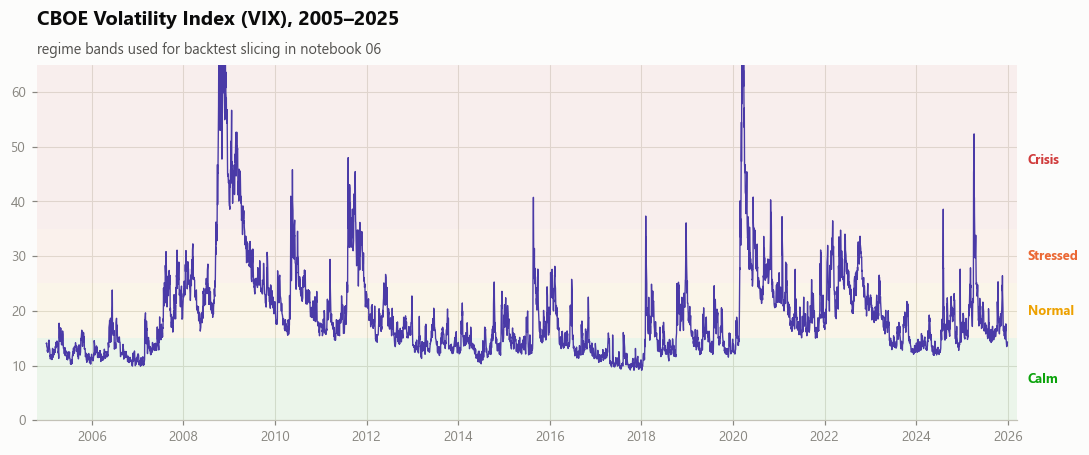

Share of trading days per regime:
vix
Normal      46.0%
Calm        37.6%
Stressed    11.6%
Crisis       4.8%
Name: proportion, dtype: str


In [8]:
vix = market["vix"].dropna()
bands = [(0, 15, "Calm", GOOD), (15, 25, "Normal", YELLOW),
         (25, 35, "Stressed", ORANGE), (35, 90, "Crisis", CRITICAL)]

fig, ax = plt.subplots(figsize=(11.5, 4.2))
for lo, hi, label, c in bands:
    ax.axhspan(lo, hi, color=c, alpha=0.07, lw=0)
    ax.text(vix.index[-1] + pd.Timedelta(days=160), (lo + min(hi, 60)) / 2, label,
            fontsize=8.5, color=c, fontweight="bold", va="center")
ax.plot(vix.index, vix, color=VIOLET, lw=0.9)
ax.set_ylim(0, 65)
ax.set_title("CBOE Volatility Index (VIX), 2005\u20132025")
subtitle(ax, "regime bands used for backtest slicing in notebook 06")
year_axis(ax)
ax.margins(x=0.01)
save_figure(fig, "eda_vix_regimes")
plt.show()

share = pd.cut(vix, [0, 15, 25, 35, 200], labels=[b[2] for b in bands]).value_counts(normalize=True)
print("Share of trading days per regime:")
print((share * 100).round(1).astype(str) + "%")

---
## 5. Correlation Structure — 48 Stocks, But Far Fewer Independent Bets

Daily-return correlations, ordered by sector. Blue = positively correlated. The diagonal blocks are sectors; the take-away is how strong the *market factor* is relative to everything else.

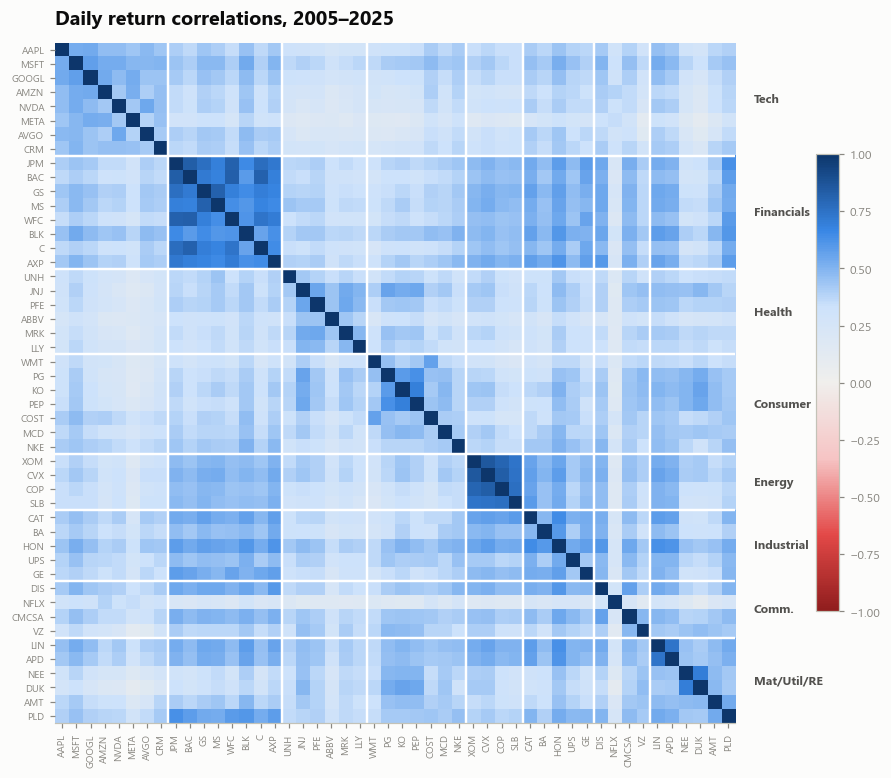

Average pairwise correlation: 0.39


In [9]:
sector_order = ["AAPL","MSFT","GOOGL","AMZN","NVDA","META","AVGO","CRM",
                "JPM","BAC","GS","MS","WFC","BLK","C","AXP",
                "UNH","JNJ","PFE","ABBV","MRK","LLY",
                "WMT","PG","KO","PEP","COST","MCD","NKE",
                "XOM","CVX","COP","SLB",
                "CAT","BA","HON","UPS","GE",
                "DIS","NFLX","CMCSA","VZ",
                "LIN","APD","NEE","DUK","AMT","PLD"]
sector_bounds = [0, 8, 16, 22, 29, 33, 38, 42, 48]
sector_names = ["Tech", "Financials", "Health", "Consumer", "Energy",
                "Industrial", "Comm.", "Mat/Util/RE"]

corr = returns[sector_order].corr()

fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(corr.values, cmap=CMAP_DIV.reversed(), vmin=-1, vmax=1)
ax.set_xticks(range(len(sector_order))); ax.set_xticklabels(sector_order, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(sector_order))); ax.set_yticklabels(sector_order, fontsize=6.5)
ax.grid(False)
for b in sector_bounds[1:-1]:
    ax.axhline(b - 0.5, color="white", lw=1.6)
    ax.axvline(b - 0.5, color="white", lw=1.6)
for name, lo, hi in zip(sector_names, sector_bounds[:-1], sector_bounds[1:]):
    ax.text(len(sector_order) + 0.8, (lo + hi) / 2 - 0.5, name, fontsize=8,
            color=INK_2, va="center", fontweight="bold")
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.09)
cbar.ax.tick_params(labelsize=8)
ax.set_title("Daily return correlations, 2005\u20132025")
save_figure(fig, "eda_correlation_matrix")
plt.show()

# how much of the universe does one factor explain?
avg_corr = corr.values[np.triu_indices_from(corr.values, k=1)].mean()
print(f"Average pairwise correlation: {avg_corr:.2f}")

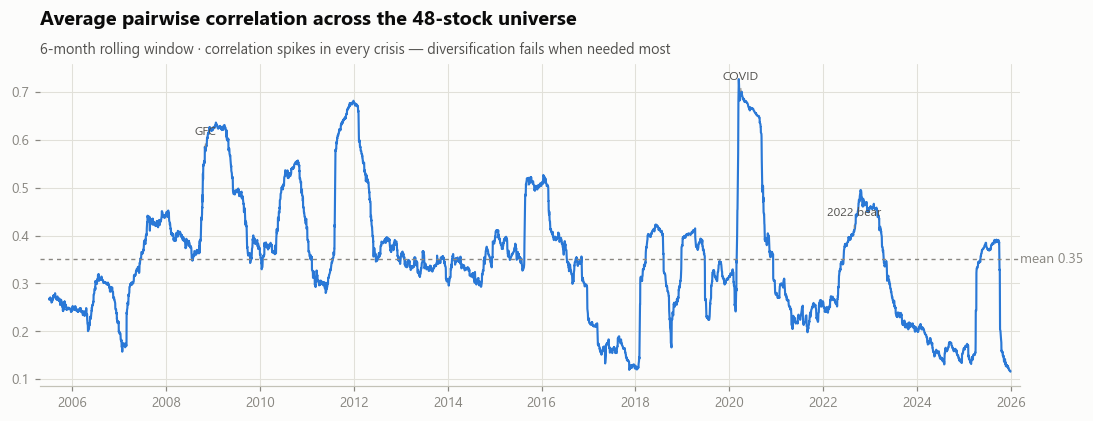

In [10]:
# Correlations are not static - they spike exactly when diversification is needed most
window = 126  # six months
pair_corr = returns[universe].rolling(window).corr().groupby(level=0).apply(
    lambda c: c.values[np.triu_indices_from(c.values, k=1)]).apply(np.nanmean)
pair_corr = pair_corr.dropna()

fig, ax = plt.subplots(figsize=(11.5, 3.8))
ax.plot(pair_corr.index, pair_corr, color=BLUE, lw=1.4)
ax.axhline(pair_corr.mean(), color=MUTED, lw=0.9, ls=(0, (3, 3)))
direct_label(ax, pair_corr.index[-1], pair_corr.mean(), f"mean {pair_corr.mean():.2f}", MUTED, weight="normal")
for date, label in [("2008-11-01", "GFC"), ("2020-04-01", "COVID"), ("2022-09-01", "2022 bear")]:
    d = pd.Timestamp(date); v = pair_corr.asof(d)
    ax.annotate(label, xy=(d, v), xytext=(0, 10), textcoords="offset points",
                fontsize=8, ha="center", color=INK_2,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.7))
ax.set_title("Average pairwise correlation across the 48-stock universe")
subtitle(ax, "6-month rolling window \u00b7 correlation spikes in every crisis \u2014 diversification fails when needed most")
year_axis(ax)
ax.margins(x=0.01)
save_figure(fig, "eda_rolling_correlation")
plt.show()

**Takeaway:** the average pairwise correlation is ~0.4 and lurches toward 0.7+ in every crisis. Two consequences: **(1)** pooling all 48 stocks into one training panel is statistically reasonable — they share one dominant factor; **(2)** a long-only portfolio of "48 independent signals" is nothing of the sort in a drawdown — the backtest must report crisis behavior explicitly.

---
## 6. Is There Anything to Predict? The Honest Check

Before building a single neural network: how much structure do next-day returns actually contain? We compare the autocorrelation of **returns** (what we want to predict) against **absolute returns** (their magnitude).

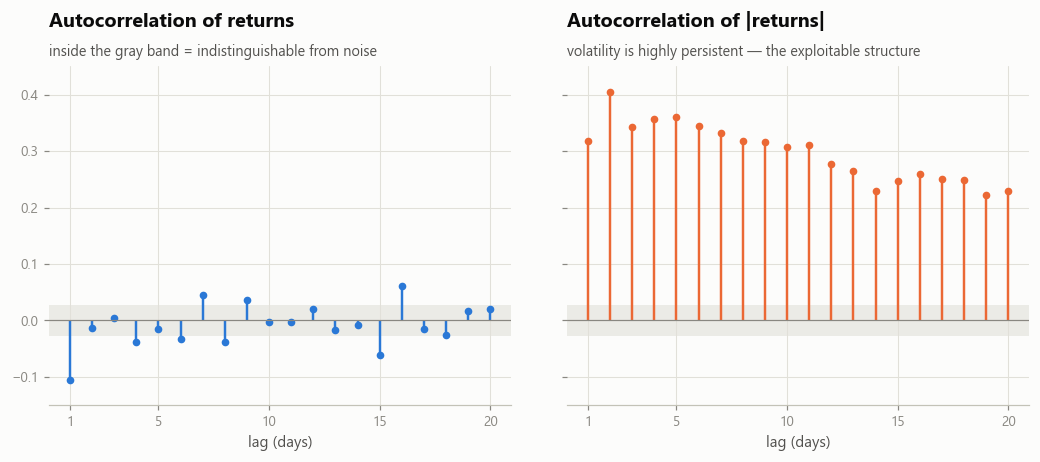

Lag-1 autocorr of returns:  -0.105
Lag-1 autocorr of |returns|: +0.318


In [11]:
from numpy.lib.stride_tricks import sliding_window_view

def acf(series, max_lag=20):
    s = series.dropna().values
    s = s - s.mean()
    denom = (s ** 2).sum()
    return np.array([1.0] + [ (s[k:] * s[:-k]).sum() / denom for k in range(1, max_lag + 1)])

lags = np.arange(0, 21)
acf_ret = acf(spy_ret)
acf_abs = acf(spy_ret.abs())
ci = 1.96 / np.sqrt(len(spy_ret))   # white-noise 95% band

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4), sharey=True,
                               gridspec_kw={"wspace": 0.12})
for ax, vals, ttl, c in [(ax1, acf_ret, "Autocorrelation of returns", BLUE),
                         (ax2, acf_abs, "Autocorrelation of |returns|", ORANGE)]:
    ax.axhspan(-ci, ci, color=GRID, alpha=0.6, lw=0)
    markerline, stemlines, baseline = ax.stem(lags[1:], vals[1:])
    plt.setp(stemlines, color=c, linewidth=1.6)
    plt.setp(markerline, color=c, markersize=4)
    baseline.set_visible(False)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_title(ttl)
    ax.set_xlabel("lag (days)")
    ax.set_xticks([1, 5, 10, 15, 20])
ax1.set_ylim(-0.15, 0.45)
subtitle(ax1, "inside the gray band = indistinguishable from noise")
subtitle(ax2, "volatility is highly persistent \u2014 the exploitable structure")
save_figure(fig, "eda_autocorrelation")
plt.show()

print(f"Lag-1 autocorr of returns:  {acf_ret[1]:+.3f}")
print(f"Lag-1 autocorr of |returns|: {acf_abs[1]:+.3f}")

**Takeaway — the most important chart for setting expectations.** Next-day *returns* are almost pure noise (lag-1 autocorrelation ≈ −0.1, and most lags inside the white-noise band). What persists is *volatility*. So:

- A model with **52–55% directional accuracy** would be genuinely good; anyone claiming 70% has a data leak.
- Features should capture **volatility state and regime** (they do: `vol_21d`, `atr_14`, VIX), not just past returns.
- The economic value of a weak signal depends entirely on **costs and turnover** — hence the 10 bps cost model in the backtest.

---
## 7. Three Benchmark Relationships, By Name

**(a) Does a single stock decouple from the market?** Rolling 60-day correlation of AAPL vs SPY. **(b) Is the VIX actually predictive?** Today's VIX against the *subsequent* 21-day realized volatility of SPY. **(c) Has participation changed?** Median daily dollar volume across the universe.

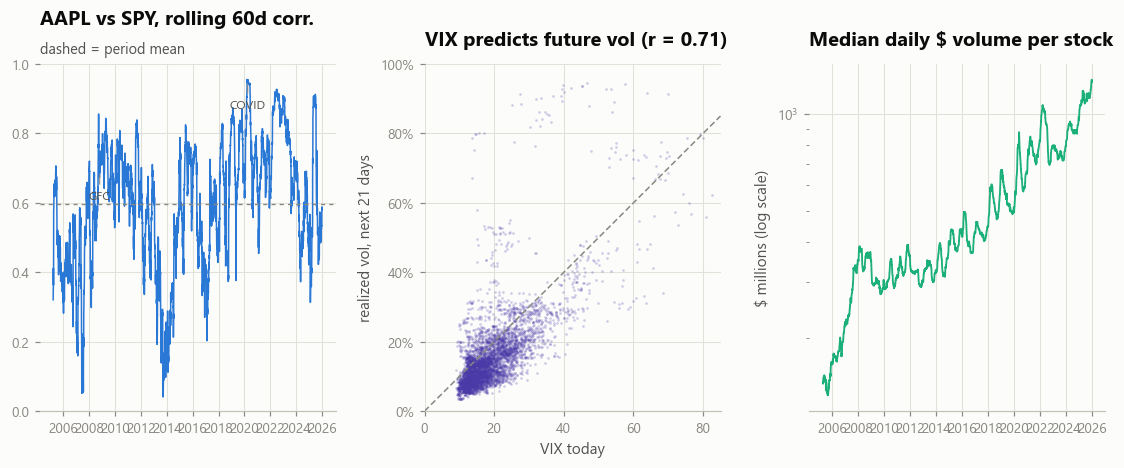

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.1), gridspec_kw={"wspace": 0.3})

# (a) AAPL vs SPY rolling 60-day correlation
roll_corr = returns["AAPL"].rolling(60).corr(returns["SPY"]).dropna()
ax = axes[0]
ax.plot(roll_corr.index, roll_corr, color=BLUE, lw=1.0)
ax.axhline(roll_corr.mean(), color=MUTED, lw=0.9, ls=(0, (3, 3)))
for date, label in [("2008-11-01", "GFC"), ("2020-04-01", "COVID")]:
    d = pd.Timestamp(date); v = roll_corr.asof(d)
    ax.annotate(label, xy=(d, v), xytext=(0, -18), textcoords="offset points",
                fontsize=8, ha="center", color=INK_2,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.7))
ax.set_title("AAPL vs SPY, rolling 60d corr.")
ax.set_ylim(0, 1)
year_axis(ax)

# (b) VIX today vs SPY realized vol over the NEXT 21 days
fwd_vol = (spy_ret.rolling(21).std() * np.sqrt(252)).shift(-21)
pair = pd.concat([market["vix"], fwd_vol], axis=1, keys=["vix", "fwd_vol"]).dropna()
ax = axes[1]
ax.scatter(pair["vix"], pair["fwd_vol"], s=3, alpha=0.25, color=VIOLET, linewidths=0)
lims = [0, 85]
ax.plot(lims, [v / 100 for v in lims], color=MUTED, lw=1, ls=(0, (4, 2)))
ax.set_xlim(0, 85); ax.set_ylim(0, 1.0)
ax.set_xlabel("VIX today")
ax.set_ylabel("realized vol, next 21 days")
fmt_pct(ax)
r_iv = pair["vix"].corr(pair["fwd_vol"])
ax.set_title(f"VIX predicts future vol (r = {r_iv:.2f})")

# (c) median daily dollar volume across the 48-stock universe
volume_w = data.pivot_field(prices, "Volume")[universe]
dollar_vol = (volume_w * close[universe]).median(axis=1).rolling(63).median().dropna()
ax = axes[2]
ax.plot(dollar_vol.index, dollar_vol / 1e6, color=AQUA, lw=1.2)
ax.set_yscale("log")
ax.set_title("Median daily $ volume per stock")
ax.set_ylabel("$ millions (log scale)")
year_axis(ax)
subtitle(axes[0], "dashed = period mean")
save_figure(fig, "eda_benchmark_relationships")
plt.show()

**Reading:** (a) AAPL's market correlation averages ~0.6 and *rises* toward 0.9 in crises — single names offer least independence exactly when it matters. (b) The VIX genuinely forecasts realized volatility (the points hug the VIX/100 diagonal) — which is why it earns its place as a model feature and as the backtest's regime variable. (c) Dollar volume grew by an order of magnitude over two decades — supporting the 10 bps cost assumption for these names today, and cautioning that early-sample liquidity was thinner.

### Sharpe leaderboard — best and worst of two decades

In [13]:
lb = summary[~summary["Ticker"].isin(config.BENCHMARKS)].set_index("Ticker")
leader = pd.concat([lb.nlargest(10, "Sharpe Ratio"),
                    lb.nsmallest(10, "Sharpe Ratio").sort_values("Sharpe Ratio")])
leader[["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"]].round(3)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Ticker,,,,
AVGO,0.3500,0.3780,0.9260,-0.5220
AAPL,0.2700,0.3220,0.8400,-0.6740
COST,0.1570,0.2240,0.7020,-0.5190
ABBV,0.1850,0.2650,0.6980,-0.4960
NVDA,0.3320,0.4870,0.6810,-0.9000
MCD,0.1360,0.2000,0.6780,-0.4000
GOOGL,0.1970,0.3000,0.6570,-0.6980
LLY,0.1700,0.2610,0.6520,-0.5640
NFLX,0.3010,0.5000,0.6030,-0.8820


---
## 8. Risk and Return Across the Universe

Twenty-year summary statistics per stock (from the data pipeline), as one risk/return map.

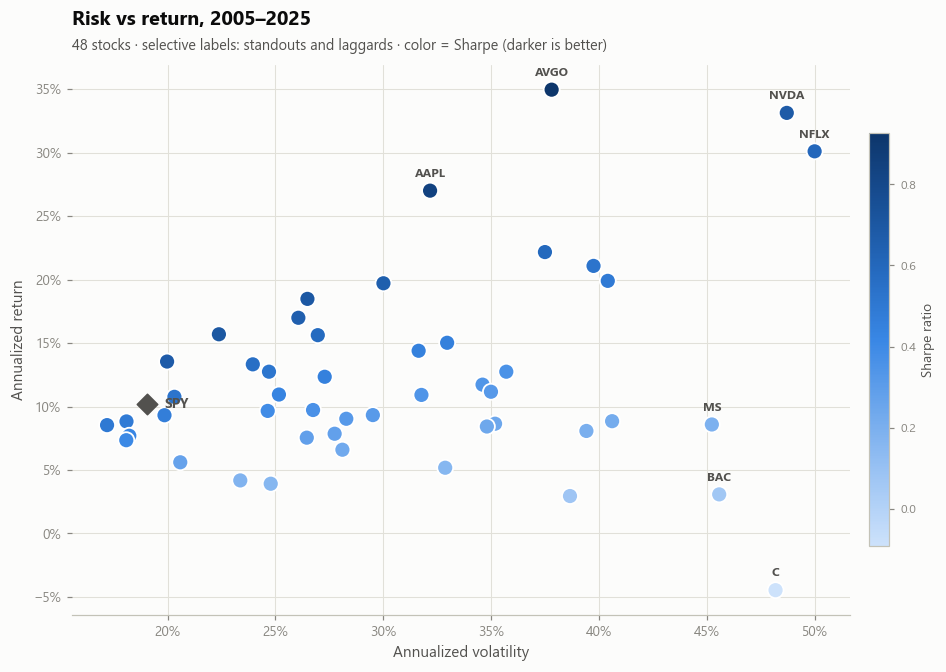

In [14]:
s = summary[~summary["Ticker"].isin(config.BENCHMARKS)].copy()
spy_row = summary[summary["Ticker"] == "SPY"].iloc[0]

fig, ax = plt.subplots(figsize=(11, 6.5))
sc = ax.scatter(s["Annualized Volatility"], s["Annualized Return"],
                s=110, c=s["Sharpe Ratio"], cmap=plotting.CMAP_SEQ,
                edgecolors="white", linewidths=1.2, zorder=3)
ax.scatter(spy_row["Annualized Volatility"], spy_row["Annualized Return"],
           marker="D", s=90, color=INK_2, zorder=4)
direct_label(ax, spy_row["Annualized Volatility"], spy_row["Annualized Return"], "SPY", INK_2, dx=11)

for _, row in s.iterrows():
    if row["Sharpe Ratio"] > 0.75 or row["Annualized Return"] < 0.02 or row["Annualized Volatility"] > 0.42:
        ax.annotate(row["Ticker"], (row["Annualized Volatility"], row["Annualized Return"]),
                    xytext=(0, 9), textcoords="offset points", fontsize=8,
                    ha="center", color=INK_2, fontweight="bold")

cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Sharpe ratio", fontsize=9, color=INK_2)
cbar.ax.tick_params(labelsize=8)
ax.set_title("Risk vs return, 2005\u20132025")
subtitle(ax, "48 stocks \u00b7 selective labels: standouts and laggards \u00b7 color = Sharpe (darker is better)")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized return")
fmt_pct(ax, "x"); fmt_pct(ax, "y")
save_figure(fig, "eda_risk_return_map")
plt.show()

---
## 9. What This Means for Notebooks 02–06

| Finding | Modeling decision it drives |
|---|---|
| Fat tails, kurtosis ≈ 11 | Judge models on directional accuracy + Sharpe, not MSE alone |
| Volatility clusters; VIX regimes | `vol_21d`, `atr_14`, VIX features; regime-sliced backtest |
| Avg pairwise correlation ≈ 0.4, spiking in crises | Pool all 48 stocks into one training panel; report crisis drawdowns honestly |
| Return autocorrelation ≈ noise | Expect 52–55% directional accuracy at best; treat anything higher as a leak |
| Non-stationarity across two decades | Strict temporal splits (2005–18 / 2019–21 / 2022–25) + walk-forward validation |
| Shorter histories for META, ABBV, AVGO… | Per-ticker rolling features that start when the ticker starts |

**Next:** notebook `02_preprocessing.ipynb` turns these observations into a leak-free feature matrix — 17 features per (date, stock), scaled with statistics fit on the training years only.